In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

[1 0 4 1 3 1]


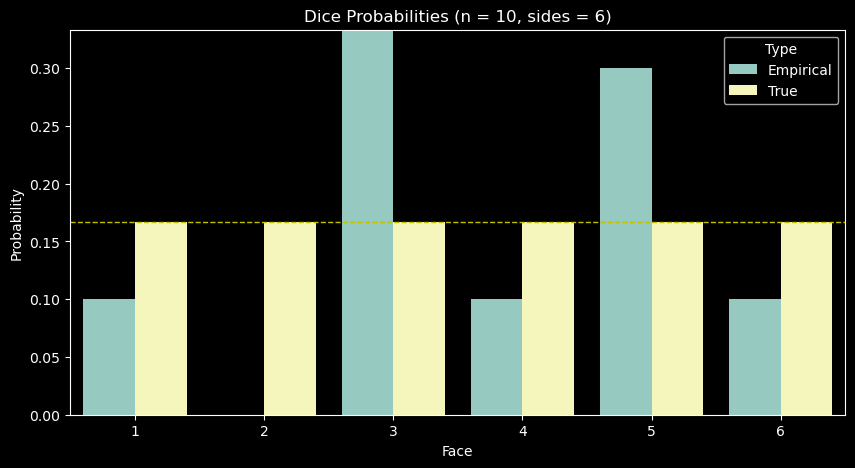

In [35]:
# ---------------------------------------------
# PARAMETERS
# ---------------------------------------------
num_sides = 6         # <---- number of sides on die
num_rolls = 10        # <---- adjust sample size

# ---------------------------------------------
# SIMULATE FAIR DIE ROLLS
# ---------------------------------------------
rolls = np.random.randint(1, num_sides + 1, size=num_rolls)

# Robust counting: always length = num_sides
counts = np.zeros(num_sides, dtype=int)
unique_vals, unique_counts = np.unique(rolls, return_counts=True)
for v, c in zip(unique_vals, unique_counts):
    counts[v - 1] = c

print(counts)

empirical_freq = counts / num_rolls
true_probs = np.full(num_sides, 1 / num_sides)

# Build DataFrame
df = pd.DataFrame({
    "Face": np.arange(1, num_sides + 1),
    "Empirical": empirical_freq,
    "True": true_probs
})

# ---------------------------------------------
# PLOT — EMPIRICAL VS TRUE PROBABILITIES
# ---------------------------------------------
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df.melt(id_vars="Face", var_name="Type", value_name="Probability"),
    x="Face", y="Probability", hue="Type"
)

# Add dashed horizontal line for the true probability
plt.axhline(1/num_sides, color="y", linestyle="--", linewidth=1)

plt.ylim(0, max(true_probs) * 2)
plt.title(f"Dice Probabilities (n = {num_rolls}, sides = {num_sides})")
plt.show()

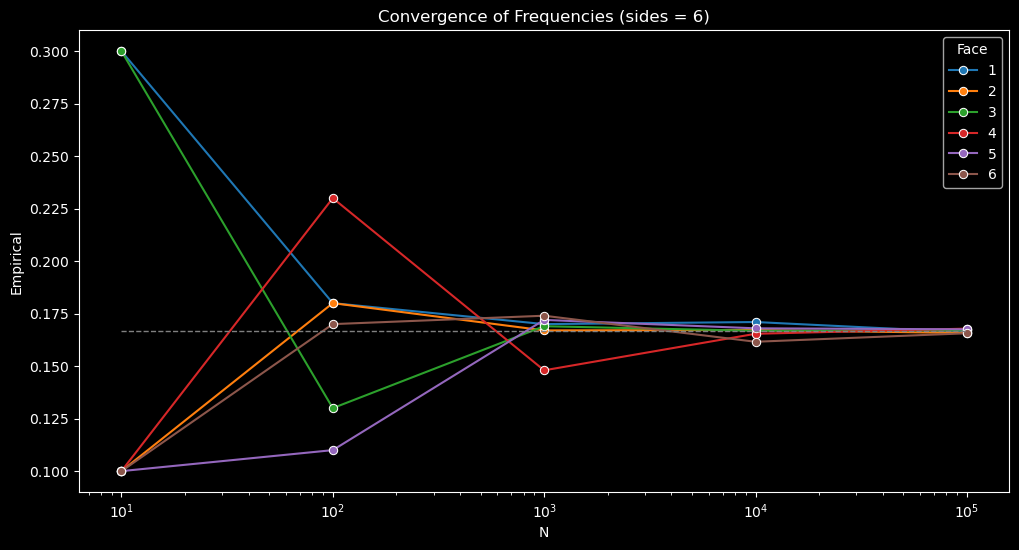

In [36]:
# ---------------------------------------------
# SHOW CONVERGENCE AS N INCREASES
# ---------------------------------------------
sample_sizes = [10, 100, 1000, 10000, 100000]
records = []

for N in sample_sizes:
    r = np.random.randint(1, num_sides + 1, size=N)
    countsN = np.zeros(num_sides, dtype=int)
    u, c = np.unique(r, return_counts=True)
    for v, cc in zip(u, c):
        countsN[v - 1] = cc
    freq = countsN / N

    for face in range(1, num_sides + 1):
        records.append({"N": N, "Face": face, "Empirical": freq[face - 1]})

df_conv = pd.DataFrame(records)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_conv,
    x="N",
    y="Empirical",
    hue="Face",
    marker="o",
    palette="tab10"   # <---- categorical palette
)

plt.hlines(
    1/num_sides,
    xmin=min(sample_sizes),
    xmax=max(sample_sizes),
    colors="gray",
    linestyles="--",
    linewidth=1
)

plt.xscale("log")
plt.title(f"Convergence of Frequencies (sides = {num_sides})")
plt.show()